In [19]:
from einops import rearrange, reduce
import cv2
import numpy as np
from matplotlib.pyplot import imshow

In [4]:
images = np.load('../assets/test_images.npy')
print(images)

[[[[1.         0.90196078 0.90196078]
   [1.         0.90196078 0.90196078]
   [1.         0.90196078 0.90196078]
   ...
   [1.         0.90196078 0.90196078]
   [1.         0.90196078 0.90196078]
   [1.         0.90196078 0.90196078]]

  [[1.         0.90196078 0.90196078]
   [1.         0.90196078 0.90196078]
   [1.         0.90196078 0.90196078]
   ...
   [1.         0.90196078 0.90196078]
   [1.         0.90196078 0.90196078]
   [1.         0.90196078 0.90196078]]

  [[1.         0.90196078 0.90196078]
   [1.         0.90196078 0.90196078]
   [1.         0.90196078 0.90196078]
   ...
   [1.         0.90196078 0.90196078]
   [1.         0.90196078 0.90196078]
   [1.         0.90196078 0.90196078]]

  ...

  [[1.         0.90196078 0.90196078]
   [1.         0.90196078 0.90196078]
   [1.         0.90196078 0.90196078]
   ...
   [1.         0.90196078 0.90196078]
   [1.         0.90196078 0.90196078]
   [1.         0.90196078 0.90196078]]

  [[1.         0.90196078 0.90196078]
   [1. 

In [5]:
print(images.shape)

(6, 96, 96, 3)


### Exercise 1: Convert to Channel-First Format

You have images in (batch, height, width, channels) format. A common format for deep learning frameworks is (batch, channels, height, width). Use rearrange to convert ims to this format.

In [6]:
transposed = rearrange(images, 'b h w c -> b c h w')
print(transposed.shape)

(6, 3, 96, 96)


### Exercise 2: Flatten Each Image into a Vector

For each image in the batch, flatten its height, width, and channel dimensions into a single dimension. The output should be a 2D tensor where each row is a flattened image.



In [8]:
flattened = rearrange(images, 'b h w c -> b (h w c)')
print(flattened.shape)

(6, 27648)


### Exercise 3: Create 2x2 Image Patches

Divide each 96x96 image into 2x2 non-overlapping patches. The output should have dimensions (batch, num_patches_h, num_patches_w, patch_h, patch_w, channels). Then, rearrange this to combine batch, num_patches_h, and num_patches_w into a single "total patches" dimension.

In [13]:
patch_divided_images = rearrange(images, 'b (h1 h) (w1 w) c -> b h1 w1 h w c', h1=48, w1=48)
print(patch_divided_images.shape)

(6, 48, 48, 2, 2, 3)


In [ ]:
total_patches = rearrange(patch_divided_images, 'b h1 w1 h w c -> (b h1 w1) h w c')
print(total_patches.shape)

(13824, 2, 2, 3)


### Exercise 4: Add a "Color Dimension" to a Grayscale Image

Imagine ims[0, ..., 0] (the first image, first channel) is a grayscale image with shape (96, 96). Use rearrange to add a channel dimension of size 1, making its shape (96, 96, 1).

Create the grayscaled image

(6, 96, 96)


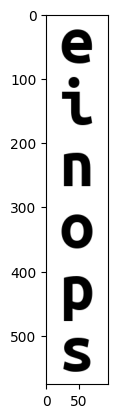

In [24]:
grayscaled = reduce(images, 'b h w c -> b h w', 'mean')
collapsed = rearrange(grayscaled, 'b h w -> (b h) w')
print(grayscaled.shape)
imshow(collapsed, cmap='gray')

Add color dimension

In [32]:
grayscaled_with_color_dimension = rearrange(grayscaled, 'b (h h1) (w w1) -> b h w (h1 w1)', h1=1, w1=1)
print(grayscaled_with_color_dimension.shape)

(6, 96, 96, 1)


In [33]:
grayscaled_with_color_dimension1 = rearrange(grayscaled, 'b h w -> b h w 1')


### Exercise 5: Average Color Channels

For each image, calculate the average pixel value across its color channels. The output should be a batch of grayscale images, so the shape should be (batch, height, width).

(6, 96, 96)


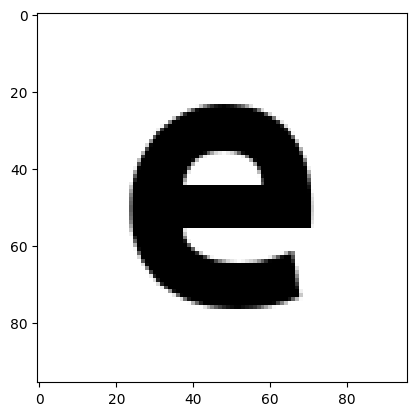

In [36]:
grayscaled = reduce(images, 'b h w c -> b h w', 'mean')
print(grayscaled.shape)
imshow(grayscaled[0], cmap='gray')

### Exercise 6: Find the Brightest Pixel Value Per Channel Per Image

For each image, find the maximum pixel intensity value for each of its color channels. The output should be a 2D tensor of shape (batch, channels).

In [39]:
max_pooled_images = reduce(images, 'b h w c -> b c', 'max')
print(max_pooled_images.shape)

(6, 3)


### Exercise 7: Reshape Batch and Height for Display

You want to display all images side-by-side in a single row, similar to the tutorial's (b h) w c example, but instead, you want to stack them vertically. Rearrange ims so that b and w are composed into a new width dimension, and h remains separate. The output should be (height, new_width, channels).

(96, 576, 3)


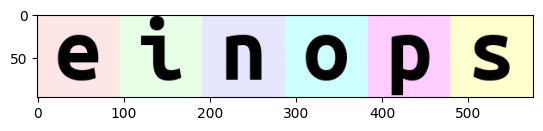

In [41]:
stacked_images = rearrange(images, 'b h w c -> h (b w) c')
print(stacked_images.shape)
imshow(stacked_images)

### Exercise 8: Create a Batch of "Checkerboard" Patches

Assume you want to split each image into 2x2 blocks, but you want to treat the "horizontal" and "vertical" components of these blocks as separate dimensions. For example, if an image is H x W, you want to get H/2 x W/2 blocks, where each block internally has 2 x 2 pixels. Rearrange ims to have the shape (batch, num_blocks_h, num_blocks_w, block_h, block_w, channels).



In [43]:
checkerboard_images = rearrange(images, 'b (num_blocks_h block_h) (num_blocks_w block_w) c -> b num_blocks_h num_blocks_w block_h block_w c', block_h=2, block_w=2)
print(checkerboard_images.shape)

(6, 48, 48, 2, 2, 3)
